In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%cd ..

/workspaces/API-macroecon-wrappy


In [2]:
import sys
sys.path.append('/workspaces/API-macroecon-wrappy')

In [9]:
from macroecon_wrappy import Auth

import pandas as pd
import QuantLib as ql

from pathlib import Path
import pprint

secrets_path = Path('/workspaces/API-macroecon-wrappy/SECRETS.yaml')
cache_path = Path('/workspaces/API-macroecon-wrappy/tests/tmp/')
auth = Auth(secrets_path, cache_path)
auth.load_secrets()

True

In [13]:

# Fetch current US Treasury yield curve
df_curve = auth.obb.fixedincome.government.yield_curve(
    provider="fred"
)
print(df_curve.head())

           maturity    rate  maturity_years
date                                       
2026-06-09  month_1  0.0369        0.083333
2026-06-09  month_3  0.0379        0.250000
2026-06-09  month_6  0.0382        0.500000
2026-06-09   year_1  0.0390        1.000000
2026-06-09   year_2  0.0413        2.000000


In [17]:
# 1. OpenBB yields are typically in percentages (e.g., 4.5), QuantLib expects decimals (0.045)
nominal_rates = (df_curve['rate'] / 100.0).tolist()

# 2. Setup QuantLib environment
calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
today = ql.Date.todaysDate()
ql.Settings.instance().evaluationDate = today

# 3. Map maturities to exact future target dates in QuantLib
dates = [today] # Curve starts today
for m in df_curve['maturity_years']:
    # Convert fractional years to days or months roughly
    days = int(m * 365)
    dates.append(calendar.advance(today, ql.Period(days, ql.Days)))

# Prepend a spot rate for 'today' (usually matching the shortest maturity rate)
rates = [nominal_rates[0]] + nominal_rates

In [23]:
# 4. Instantiate the QuantLib YieldTermStructure
day_count = ql.Actual360()
compounding = ql.Continuous
compounding_frequency = ql.Annual

yield_term_structure = ql.ZeroCurve(
    dates, 
    rates, 
    day_count, 
    calendar, 
    ql.Linear(), # Interpolation type
    compounding, 
    compounding_frequency
)
yield_term_structure.enableExtrapolation()

# 5. Utilize the Term Structure object
# Automatically interpolates a rate for an exact point, e.g., 1.5 years out
target_date = calendar.advance(today, ql.Period(18, ql.Months))
zero_rate = yield_term_structure.zeroRate(target_date, day_count, compounding).rate()

print(f"Interpolated 18-Month Zero Rate: {zero_rate * 100:.4f}%")

Interpolated 18-Month Zero Rate: 0.0391%


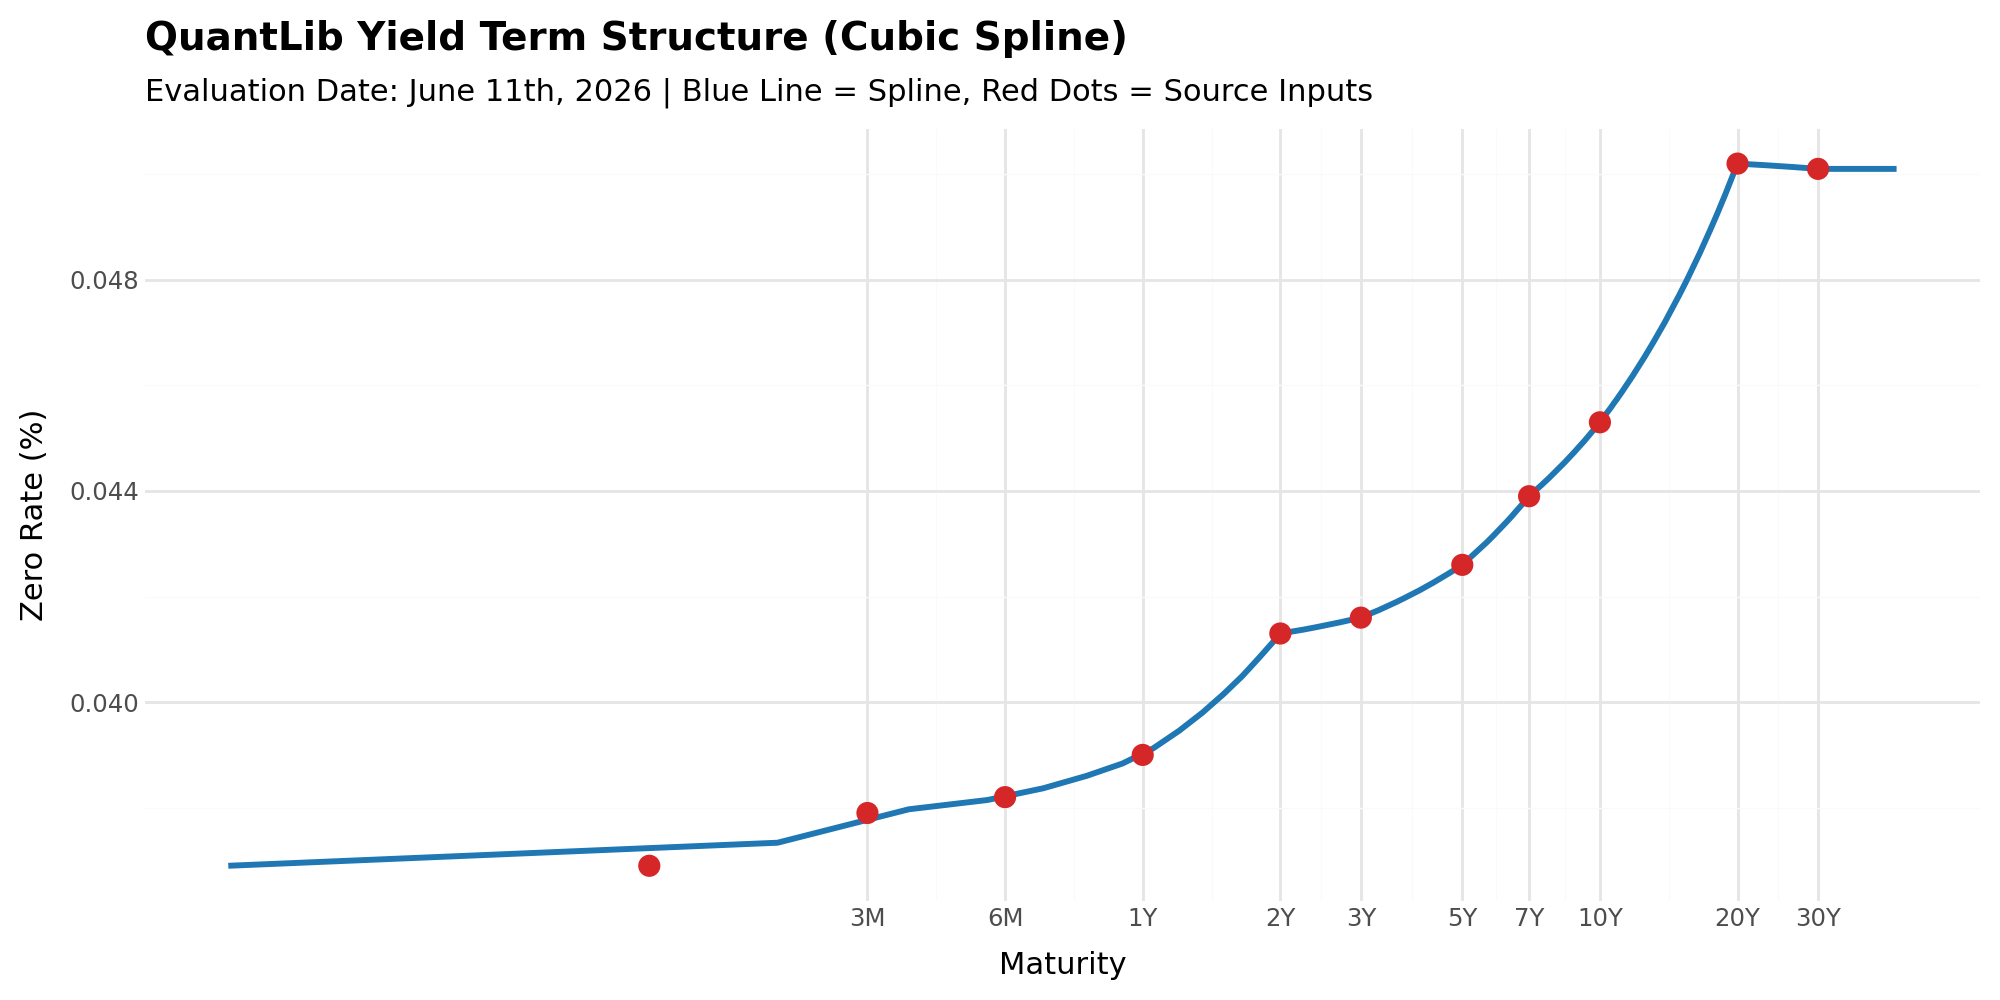

In [ ]:
# Raw input variables extracted from your original OpenBB data pull
maturities_input = df_curve['maturity_years']
rates_input      = df_curve['rate']

# Generate your plot
visual_plot = plot_quantlib_log_curve_with_points(
    yield_term_structure=yield_term_structure, 
    raw_maturities=maturities_input, 
    raw_rates=rates_input
)
visual_plot.show()

### Functions

In [46]:
import QuantLib as ql
import numpy as np
import pandas as pd
from plotnine import ggplot, aes, geom_line, geom_point, labs, theme_minimal, theme, element_text, scale_x_continuous

def plot_quantlib_log_curve_with_points(yield_term_structure, raw_maturities, raw_rates, num_points=300):
    """
    Plots a QuantLib YieldTermStructure on a natural log scale using plotnine.
    Overlays original benchmark node inputs as distinct scatter points.
    
    Parameters:
    -----------
    yield_term_structure : ql.YieldTermStructure
    raw_maturities : list or np.array
        The original timeline node positions in fractional years (e.g. [0.25, 2.0, 10.0])
    raw_rates : list or np.array
        The original input nominal rates in percentage format (e.g. [4.25, 4.30, 4.22])
    """
    # 1. Setup internal QuantLib parameters based on current evaluation date
    today = ql.Settings.instance().evaluationDate
    calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
    day_count = ql.Actual360()
    
    # Safely find the curve boundaries
    max_date = yield_term_structure.maxDate()
    max_years = day_count.yearFraction(today, max_date)
    
    # 2. Extract continuous data from QuantLib for the line plot
    time_grid = np.linspace(0.01, max_years, num_points)
    line_data = []
    
    for t in time_grid:
        days = int(t * 365.25)
        future_date = calendar.advance(today, ql.Period(days, ql.Days))
        
        if future_date > max_date:
            future_date = max_date
            
        zero_rate_obj = yield_term_structure.zeroRate(future_date, day_count, ql.Continuous)
        rate_percent = zero_rate_obj.rate() * 100
        line_data.append({"Maturity": t, "Rate": rate_percent})
        
    df_line = pd.DataFrame(line_data)
    df_line["Log_Maturity"] = np.log(df_line["Maturity"])
    
    # 3. Pack original inputs into a separate dataframe for scatter plotting
    df_points = pd.DataFrame({
        "Maturity": raw_maturities,
        "Rate": raw_rates
    })
    # Transform raw maturities to the exact same log space coordinates
    df_points["Log_Maturity"] = np.log(df_points["Maturity"])
    
    # 4. Setup clean maturity milestone targets for the X-axis
    benchmark_maturities = [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]
    clean_tick_labels = ["3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]
    
    # Filter milestones to prevent looking past the max timeline of the curve object
    final_breaks = [b for b in benchmark_maturities if b <= max_years]
    final_labels = clean_tick_labels[:len(final_breaks)]
    log_space_breaks = [np.log(b) for b in final_breaks]
    
    # Create mapping table for formatting
    label_mapping_table = dict(zip(log_space_breaks, final_labels))
    
    def clean_axis_formatter(x_axis_values):
        output_string_labels = []
        for coordinate in x_axis_values:
            matched_text = None
            for target_log_break, label_string in label_mapping_table.items():
                if np.isclose(coordinate, target_log_break, atol=1e-1):
                    matched_text = label_string
                    break
            output_string_labels.append(matched_text if matched_text else "")
        return output_string_labels

    # 5. Build visualization mapping the distinct layers
    curve_plot = (
        ggplot()
        # Layer 1: Continuous Smooth Interpolation Line
        + geom_line(df_line, aes(x="Log_Maturity", y="Rate"), color="#1f77b4", size=1.2)
        # Layer 2: Original Data Scatter Nodes Overlay
        + geom_point(df_points, aes(x="Log_Maturity", y="Rate"), color="#d62728", size=3.5)
        + scale_x_continuous(
            breaks=log_space_breaks,
            labels=clean_axis_formatter
        )
        + labs(
            title="QuantLib Yield Term Structure (Cubic Spline)",
            subtitle=f"Evaluation Date: {today} | Blue Line = Spline, Red Dots = Source Inputs",
            x="Maturity",
            y="Zero Rate (%)"
        )
        + theme_minimal()
        + theme(
            plot_title=element_text(face="bold", size=14),
            figure_size=(10, 5)
        )
    )
    
    return curve_plot
